In [1]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
from scipy.integrate import solve_ivp
from sklearn.metrics import root_mean_squared_error
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error
import pathlib
import pandas as pd
import time
import warnings
import inspect
import pysindy.differentiation as ps_diff
warnings.filterwarnings("ignore")
import os
import glob
import re
import pysindy as ps
from pysindy.feature_library import CustomLibrary
from pysindy.optimizers import STLSQ

# Seed the random number generators for reproducibility
np.random.seed(100)

# integration keywords for solve_ivp, typically needed for chaotic systems
integrator_keywords = {}
integrator_keywords["rtol"] = 1e-12
integrator_keywords["method"] = "LSODA"
integrator_keywords["atol"] = 1e-12

In [60]:
#Process raw data to remove any rows with -ve SOC

# Define the input subdirectory path under the current directory
INPUT_DIR = "Data"

# Find all CSV files in the 'Data' subdirectory
csv_files = glob.glob(os.path.join(INPUT_DIR, "*.csv"))

if not csv_files:
    print(f"No CSV files found in the '{INPUT_DIR}' subdirectory.")
else:
    print(f"Found {len(csv_files)} CSV files. Starting batch processing...")

    for file_path in csv_files:
        # Get the bare filename (e.g., "B9_data-run1.csv" or "B9-data_run1.csv")
        base_name = os.path.basename(file_path)
        # Split out the root name and extension (e.g., "B9_data-run1", ".csv")
        filename_root, file_ext = os.path.splitext(base_name)
        
        # --- UPDATED STRIPPING LOGIC ---
        # re.split(r'[-_]', ...) splits the string at the first occurrence of EITHER - or _
        # [0] grabs the very first portion before that character
        new_filename_root = re.split(r'[-_]', filename_root)[0]
        new_base_name = f"{new_filename_root}{file_ext}"
        
        # Save directly to the current directory root
        new_file_path = new_base_name
        
        print(f"Processing: {INPUT_DIR}/{base_name} --> Saved to Current Dir: {new_base_name}")
        
        try:
            # 1. Read the CSV file from 'Data/'
            df = pd.read_csv(file_path)
            
            # Verify required columns exist before performing operations
            required_cols = ["Terminal voltage [V]", "State of Charge", "Current [A]"]
            missing_cols = [col for col in required_cols if col not in df.columns]
            
            if missing_cols:
                print(f"  --> SKIPPED: Missing required source columns: {missing_cols}")
                continue

            # 2. Add new columns mapped to existing column values
            df["V"] = df["Terminal voltage [V]"]
            df["SOC"] = df["State of Charge"]
            df["I"] = df["Current [A]"]
            
            # 3. Filter rows where SOC is less than 0.0 (keep only SOC >= 0.0)
            initial_row_count = len(df)
            df = df[df["SOC"] >= 0.0]
            deleted_rows = initial_row_count - len(df)
            
            # 4. Save the modified DataFrame to the current directory root
            df.to_csv(new_file_path, index=False)
            print(f"  --> SUCCESS: Wrote new file. Cleared {deleted_rows} negative SOC rows.")
            
        except Exception as e:
            print(f"  --> ERROR processing {base_name}: {e}")

    print("\nAll files processed successfully!")

Found 5 CSV files. Starting batch processing...
Processing: Data/UDDS_results.csv --> Saved to Current Dir: UDDS.csv
  --> SUCCESS: Wrote new file. Cleared 4574 negative SOC rows.
Processing: Data/Pseudo-Random_Limit_Based_results.csv --> Saved to Current Dir: Pseudo.csv
  --> SUCCESS: Wrote new file. Cleared 0 negative SOC rows.
Processing: Data/WLTP_results.csv --> Saved to Current Dir: WLTP.csv
  --> SUCCESS: Wrote new file. Cleared 8557 negative SOC rows.
Processing: Data/HWFET_results.csv --> Saved to Current Dir: HWFET.csv
  --> SUCCESS: Wrote new file. Cleared 6231 negative SOC rows.
Processing: Data/US06_results.csv --> Saved to Current Dir: US06.csv
  --> SUCCESS: Wrote new file. Cleared 3539 negative SOC rows.

All files processed successfully!


In [2]:
# =====================================================================
# DATA SPLITTING FUNCTION
# =====================================================================
def get_sindy_data_split(set_index=0):
    """
    Scans the current directory for CSV files, builds a dictionary of 
    [X, u] arrays, and returns a specific training/validation split.
    
    Parameters:
    -----------
    set_index : int
        An index from 0 to n-1 indicating which file to use for validation.
        
    Returns:
    --------
    X_train : list of np.ndarray
        List of state matrices for PySINDy training.
    u_train : list of np.ndarray
        List of input matrices for PySINDy training.
    X_val : np.ndarray
        State matrix for model validation.
    u_val : np.ndarray
        Input matrix for model validation.
    val_key : str
        The name of the file used for validation (useful for tracking/logging).
    """
    # Find all CSV files in the current working directory root
    csv_files = sorted(glob.glob("*.csv"))
    
    dataset_dict = {}
    
    # Load and parse files into the dictionary
    for file_path in csv_files:
        file_root = os.path.splitext(os.path.basename(file_path))[0]
        try:
            df = pd.read_csv(file_path)
            if not all(col in df.columns for col in ["V", "SOC", "I"]):
                continue
                
            X_arr = df[["V", "SOC"]].to_numpy(dtype=np.float64)
            u_arr = df[["I"]].to_numpy(dtype=np.float64)
            dataset_dict[file_root] = [X_arr, u_arr]
        except Exception as e:
            print(f"Error loading {file_path}: {e}")

    all_keys = list(dataset_dict.keys())
    n_files = len(all_keys)
    
    if n_files < 2:
        raise ValueError(f"Found only {n_files} valid datasets. At least 2 are required for splitting.")
        
    if set_index < 0 or set_index >= n_files:
        raise IndexError(f"set_index {set_index} is out of bounds for {n_files} datasets.")
        
    # Isolate the validation key based on the provided index
    val_key = all_keys[set_index]
    train_keys = [key for key in all_keys if key != val_key]
    
    # Extract validation arrays
    X_val, u_val = dataset_dict[val_key]
    
    # Extract and pool training arrays into lists
    X_train = []
    u_train = []
    for key in train_keys:
        X_arr, u_arr = dataset_dict[key]
        X_train.append(X_arr)
        u_train.append(u_arr)
        
    return X_train, u_train, X_val, u_val, val_key

In [3]:
# =====================================================================
# CUSTOM LIBRARY FUNCTION
# =====================================================================
def getCustomLib():

    #Candidate terms

    # State Mapping: x[0]=V, x[1]=SOC, x[2]=I
    functions = [
        # --- Category 1: Constant/Bias (1 term) ---
        lambda x: 1,

        # --- Category 2: Linear Polynomials (2 terms) ---
        lambda x: x[0],      # V
        lambda x: x[1],      # SOC
        lambda x: x[2],      # I

        # --- Category 3: Pure Quadratic Polynomials (2 terms) ---
        lambda x: x[0]**2,   # V^2
        lambda x: x[1]**2,   # SOC^2
        lambda x: x[2]**2,   # I^2

        # --- Category 4: Bilinear Cross-Products; higher order polynomials (7 terms) ---
        lambda x: x[0]*x[2], # V*I
        lambda x: x[0]*x[1], # V*SOC
        lambda x: x[1]*x[2], # SOC*I
        lambda x: x[0]**3, # V^3
        lambda x: x[0]**4, # V^4
        lambda x: 1/(x[0]**2+1), # 1/(V^2 + 1)
        lambda x: x[2]**3, # I^3
        lambda x: x[2]**4, # I^4
        lambda x: 1/(x[2]**2+1), # 1/(I^2 + 1)

        # --- Category 5: Exponentials (3 terms) ---
        lambda x: np.exp(x[0]),  # exp(V)
        lambda x: np.exp(-x[0]), # exp(-V)
        lambda x: np.exp(x[1]),  # exp(SOC)
        lambda x: np.exp(x[2]),  # exp(I)

        # --- Category 6: Sinusoids (8 terms) ---
        lambda x: np.sin(x[0]), lambda x: np.cos(x[0]), # Sin(V), Cos(V)
        lambda x: np.sin(x[2]), lambda x: np.cos(x[1]), # Sin(I), Cos(I)
        lambda x: np.sin(2*x[0]), lambda x: np.cos(2*x[0]), # Sin(2V), Cos(2V)
        lambda x: np.sin(2*x[2]), lambda x: np.cos(2*x[1]), # Sin(2I), Cos(2I)

    ]

    # Provide a matching list of clean strings for PySINDy's print engine
    custom_string_names = [
        lambda x: "1",
        lambda x: "V",
        lambda x: "SOC",
        lambda x: "I",
        lambda x: "V^2",
        lambda x: "SOC^2",
        lambda x: "I^2",
        lambda x: "V*I",
        lambda x: "V*SOC",
        lambda x: "SOC*I",
        lambda x: "V^3",
        lambda x: "V^4",
        lambda x: "1/(V^2 + 1)",
        lambda x: "I^3",
        lambda x: "I^4",
        lambda x: "1/(I^2 + 1)",
        lambda x: "exp(V)",
        lambda x: "exp(-V)",
        lambda x: "exp(SOC)",
        lambda x: "exp(I)",
        lambda x: "Sin(V)",
        lambda x: "Cos(V)",
        lambda x: "Sin(I)",
        lambda x: "Cos(I)",
        lambda x: "Sin(2V)",
        lambda x: "Cos(2V)",
        lambda x: "Sin(2I)",
        lambda x: "Cos(2I)",
        # 
    ]

    # Pass the string names list to the CustomLibrary
    custom_lib = ps.CustomLibrary(
        library_functions=functions, 
        function_names=custom_string_names  # <-- This maps the strings to f3, f4, etc.
    )
    custom_lib.library_functions = functions
    return custom_lib

# =====================================================================
# SINDY MODEL USING TRAINING DATA
# =====================================================================

def TrainedModel(X,U, custom_lib, dt = 0.1 ,tol =0.0001, alpha = 0.005):

    """
    Inputs:
    X = State data (V, SOC)
    U = Control Input (I)
    custom_lib = a predefined library of custom candidate terms
    dt = time step
    tol = threshold for LSQTS
    alpha = Ridge regression regularization coeff
    

    Outputs:
    SINDyC model
    """
    # Increase threshold for actual sparsity, expose alpha for collinearity control
    optimizer = ps.STLSQ(threshold=0.00015, alpha=alpha, normalize_columns=True)

    # Build and fit the SINDyC model
    model = ps.SINDy(feature_library=custom_lib, optimizer=optimizer)
    model.fit(X, u=U, t=dt, feature_names=["V", "SOC", "I"])

    return model
    
    

In [4]:
# =====================================================================
# PLOT SINDY CROSS VALIDATION ERROR
# =====================================================================

def plot_sindy_validation_errors(results_dict):
    """
    Plots a dual-axis or grouped bar chart comparing the One-Step-Ahead MSE 
    for dV/dt and dSOC/dt across all validation datasets.
    
    Parameters:
    -----------
    results_dict : dict
        A dictionary where the keys are the validation file names (strings) 
        and the values are lists/tuples containing [dV_mse, dSOC_mse].
        Example: { "BatteryA": [1.2e-5, 4.5e-6], "BatteryB": [1.5e-5, 3.8e-6] }
    """
    # 1. Extract keys and separate the MSE components
    keys = list(results_dict.keys())
    dv_mses = [results_dict[k][0] for k in keys]
    dsoc_mses = [results_dict[k][1] for k in keys]
    
    # Set up bar positioning markers
    x_indices = np.arange(len(keys))
    bar_width = 0.35
    
    # 2. Create the figure plot layout
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Generate grouped bars
    rects1 = ax.bar(x_indices - bar_width/2, dv_mses, bar_width, 
                    label=r'Voltage Derivative ($\dot{V}$) MSE', color='#1f77b4', edgecolor='black', alpha=0.85)
    rects2 = ax.bar(x_indices + bar_width/2, dsoc_mses, bar_width, 
                    label=r'SOC Derivative ($\dot{\mathrm{SOC}}$) MSE', color='#2ca02c', edgecolor='black', alpha=0.85)
    
    # 3. Apply logarithmic scale if error metrics span multiple orders of magnitude
    # This prevents tiny errors from being invisible next to large spikes
    ax.set_yscale('log')
    
    # 4. Add engineering labels and text styling
    ax.set_xlabel('Validation Dataset Key (Left-Out Run)', fontsize=12, fontweight='bold', labelpad=12)
    ax.set_ylabel('Mean Squared Error (MSE) [Log Scale]', fontsize=12, fontweight='bold', labelpad=12)
    ax.set_title('SINDyC Cross-Validation Performance Across Leave-One-Out Series', fontsize=14, fontweight='bold', pad=15)
    
    # Map the text labels to the middle of our grouped clusters
    ax.set_xticks(x_indices)
    ax.set_xticklabels(keys, rotation=30, ha='right', fontsize=10)
    
    # Add layout accents
    ax.grid(True, which="both", linestyle="--", linewidth=0.5, alpha=0.5)
    ax.legend(fontsize=11, loc='upper right', frameon=True, shadow=True)
    
    plt.tight_layout()
    plt.show()

Detected 5 files. Initiating Leave-One-Group-Out pipeline...

=== RUN 1/5 | Validation Target: 'HWFET.csv' ===
  Training on 4 files. Validation rows: 321709

  Discovered Governing Equations:
(V)' = -0.003 V + -0.002 SOC +  0.004 I + -0.006 1/(V^2 + 1) +  0.001 1/(V^2 + 1) + -0.001 1/(I^2 + 1) + -0.028 exp(-V) + -0.001 exp(-V) +  0.009 exp(-V) + -0.027 Sin(V) +  0.001 Cos(V) +  0.032 Sin(I) +  0.001 Cos(I) + -0.001 Sin(2V) + -0.036 Sin(2V) + -0.002 Cos(2V) +  0.038 Sin(2I) + -0.001 Cos(2I) +  0.001 Cos(2I)
(SOC)' = -0.002 V + -0.001 SOC +  0.003 I + -0.004 1/(V^2 + 1) + -0.001 1/(I^2 + 1) + -0.018 exp(-V) +  0.006 exp(-V) + -0.017 Sin(V) +  0.001 Cos(V) +  0.020 Sin(I) +  0.001 Cos(I) + -0.022 Sin(2V) + -0.001 Cos(2V) +  0.001 Cos(2V) +  0.024 Sin(2I) + -0.001 Cos(2I) +  0.001 Cos(2I)

  Validation Results:
    -> dV/dt   One-Step-Ahead MSE: 1.097549e-04
    -> dSOC/dt One-Step-Ahead MSE: 1.045794e-09

=== RUN 2/5 | Validation Target: 'Pseudo.csv' ===
  Training on 4 files. Validation

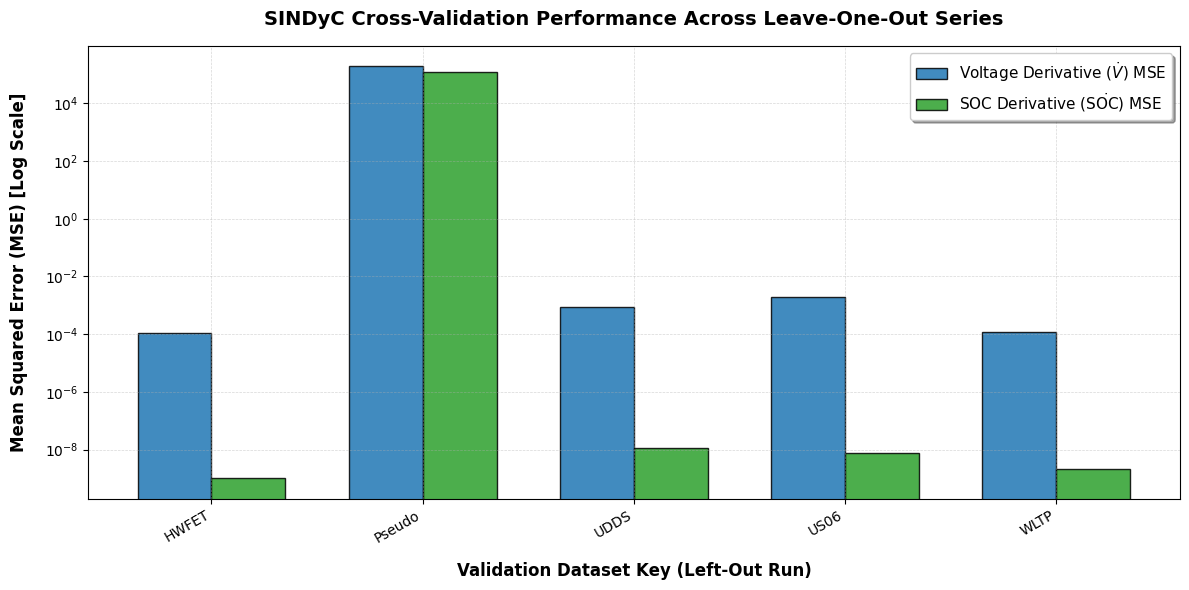

In [6]:
# =====================================================================
#MSE PLOTS FOR VARIOUS VALIDATION CASES
# =====================================================================
if __name__ == "__main__":
    # Define a quick dt time step matching your sensor sample rate (e.g., 0.1 seconds)
    dt = 0.1 

    # Create an empty dictionary for cross_val_metrics
    cross_val_metrics = {}
    
    # Find out how many valid CSV datasets exist in the folder total
    total_files = len(glob.glob("*.csv"))
    print(f"Detected {total_files} files. Initiating Leave-One-Group-Out pipeline...\n")
    
    # Loop through every available set to execute an 'n-1' cross-validation routine
    for i in range(total_files):
        try:
            # 1. Fetch data arrays from our custom function
            X_train, u_train, X_val, u_val, val_file_name = get_sindy_data_split(set_index=i)
            
            print(f"=== RUN {i+1}/{total_files} | Validation Target: '{val_file_name}.csv' ===")
            print(f"  Training on {len(X_train)} files. Validation rows: {X_val.shape[0]}")
            
            candidatelibrary = getCustomLib()
            model = TrainedModel(X_train, u_train, candidatelibrary)
            # Print the discovered system equations
            print("\n  Discovered Governing Equations:")
            model.print()
            
            # 5. Evaluate Performance via Validation Dataset Predictions
            # Predict the instantaneous derivatives of V and SOC for the validation timeline
            x_dot_predicted = model.predict(X_val, u_val)
            
            # Calculate the true derivatives using PySINDy's internal finite differentiator
            x_dot_measured = model.differentiation_method(X_val, t=dt)
            
            # Compute one-step-ahead Mean Squared Error (MSE)
            mse_errors = np.mean((x_dot_measured - x_dot_predicted) ** 2, axis=0)

            cross_val_metrics[val_file_name] = [mse_errors[0], mse_errors[1]]
            
            print(f"\n  Validation Results:")
            print(f"    -> dV/dt   One-Step-Ahead MSE: {mse_errors[0]:.6e}")
            print(f"    -> dSOC/dt One-Step-Ahead MSE: {mse_errors[1]:.6e}")
            print("="*70 + "\n")
            
        except Exception as e:
            print(f"Skipping set index {i} due to configuration warning: {e}\n")
        
    print("Metrics harvested successfully. Launching canvas generator...")
    # Call the plotting method
    plot_sindy_validation_errors(cross_val_metrics)